# Fit streams

In [277]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
import astropy.coordinates as coord
from astropy.coordinates import frame_transform_graph
from astropy.coordinates.matrix_utilities import matrix_transpose, rotation_matrix

import gala.coordinates as gc
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from gala.dynamics import mockstream as ms
_ = coord.galactocentric_frame_defaults.set('v4.0')

## Pal 5

In [2]:
pot = gp.BovyMWPotential2014(units=galactic)
H = gp.Hamiltonian(pot)

In [215]:
# odenkirchen02 + bovy16 + fritz15
# c = coord.ICRS(ra=229 * u.deg, dec=-0.124 * u.deg,
#     distance=22.9 * u.kpc,
#     pm_ra_cosdec=-2.296 * u.mas/u.yr,
#     pm_dec=-2.257 * u.mas/u.yr,
#     radial_velocity=-58.7 * u.km/u.s)

# c_gc = c.transform_to(coord.Galactocentric()).cartesian
# pal5_w0 = gd.PhaseSpacePosition(c_gc)

# koposov17
c = coord.ICRS(ra=229 * u.deg, dec=-0.111 * u.deg,
    distance=23.6 * u.kpc,
    pm_ra_cosdec=-2.23 * u.mas/u.yr,
    pm_dec=-2.22 * u.mas/u.yr,
    radial_velocity=-57.4 * u.km/u.s)

c_gc = c.transform_to(coord.Galactocentric(galcen_distance=8.3*u.kpc, galcen_v_sun=[11.1*u.km/u.s,245.0*u.km/u.s,7.3*u.km/u.s])).cartesian
pal5_w0 = gd.PhaseSpacePosition(c_gc)

In [216]:
pal5_mass = 2.5e4 * u.Msun
pal5_pot = gp.PlummerPotential(m=pal5_mass, b=4*u.pc, units=galactic)

In [280]:
df = ms.ChenStreamDF()
gen_pal5 = ms.MockStreamGenerator(df, pot, progenitor_potential=pal5_pot)
t_tot = 5000 * u.Myr
dt = 1 * u.Myr
%time stream, _ = gen_pal5.run(pal5_w0, pal5_mass, dt=-dt, n_steps=int(t_tot/dt))

CPU times: user 47.5 s, sys: 569 ms, total: 48.1 s
Wall time: 48.6 s


In [281]:
df = ms.FardalStreamDF()
gen_pal5 = ms.MockStreamGenerator(df, pot)
t_tot = 5000 * u.Myr
dt = 1 * u.Myr
%time stream_f15, _ = gen_pal5.run(pal5_w0, pal5_mass, dt=-dt, n_steps=int(t_tot/dt))

/var/folders/3r/vrbpsfwj6p52jd6wsjcvn5vh0000gr/T/ipykernel_79653/1513809620.py:1: GalaDeprecationWarning: The parameter values of the FardalStreamDF have been updated (fixed) to match the parameter values in the final published version of Fardal+2015. For now, this class uses the Gala modified parameter values that have been adopted over the last several years in Gala. In the future, the default behavior of this class will use the Fardal+2015 parameter values instead, breaking backwards compatibility for mock stream simulations. To use the Fardal+2015 parameters now, set gala_modified=False. To continue to use the Gala modified parameter values, set gala_modified=True.
  df = ms.FardalStreamDF()


CPU times: user 44.1 s, sys: 687 ms, total: 44.7 s
Wall time: 45.6 s


### RA vs. Dec

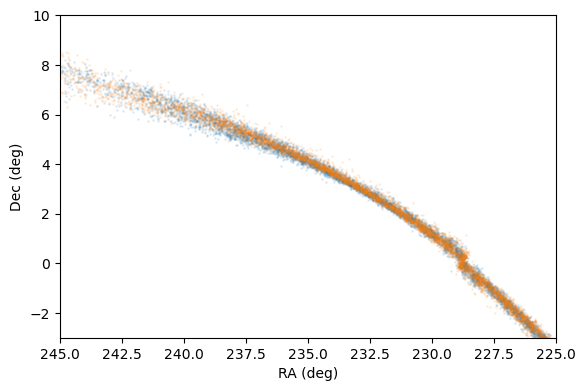

In [286]:
stream_c = stream.to_coord_frame(coord.ICRS())
stream_c_f15 = stream_f15.to_coord_frame(coord.ICRS())

plt.scatter(stream_c.ra, stream_c.dec, s=1, alpha=0.1)
plt.scatter(stream_c_f15.ra, stream_c_f15.dec, s=1, alpha=0.1)

plt.xlabel(r'RA (deg)')
plt.ylabel(r'Dec (deg)')
plt.xlim(245,225)
plt.ylim(-3,10)
plt.gca().set_aspect(1)
plt.show()

### Pal 5 great circle frame by Koposov17

In [219]:
class Pal5(coord.BaseCoordinateFrame):
    default_representation = coord.SphericalRepresentation
    default_differential = coord.SphericalCosLatDifferential

    frame_specific_representation_info = {
        coord.SphericalRepresentation: [
            coord.RepresentationMapping("lon", "phi1"),
            coord.RepresentationMapping("lat", "phi2"),
            coord.RepresentationMapping("distance", "distance"),
        ]
    }
    
PAL5_MATRIX = (
    np.diag([1.0, 1.0, 1.0])
    @ rotation_matrix((0.061977*u.deg), "z")
    @ rotation_matrix((90-53.78)*u.deg, "x")
    @ rotation_matrix((138.95+90)*u.deg, "z")
)

@frame_transform_graph.transform(coord.StaticMatrixTransform, coord.ICRS, Pal5)
def icrs_to_pal5():
    return PAL5_MATRIX

@frame_transform_graph.transform(coord.StaticMatrixTransform, Pal5, coord.ICRS)
def pal5_to_icrs():
    return matrix_transpose(PAL5_MATRIX)


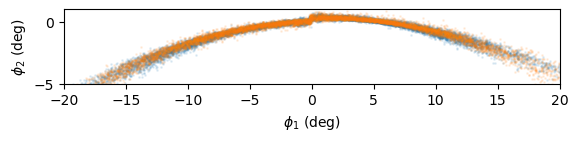

In [285]:
stream_pal5 = stream_c.transform_to(Pal5())
stream_pal5_f15 = stream_c_f15.transform_to(Pal5())

plt.scatter(stream_pal5.phi1.wrap_at(180*u.deg), stream_pal5.phi2, s=1, alpha=0.1)
plt.scatter(stream_pal5_f15.phi1.wrap_at(180*u.deg), stream_pal5_f15.phi2, s=1, alpha=0.1)

plt.xlabel(r'$\phi_1$ (deg)')
plt.ylabel(r'$\phi_2$ (deg)')
plt.xlim(-20,20)
plt.ylim(-5,1)
plt.gca().set_aspect(1)
plt.show()

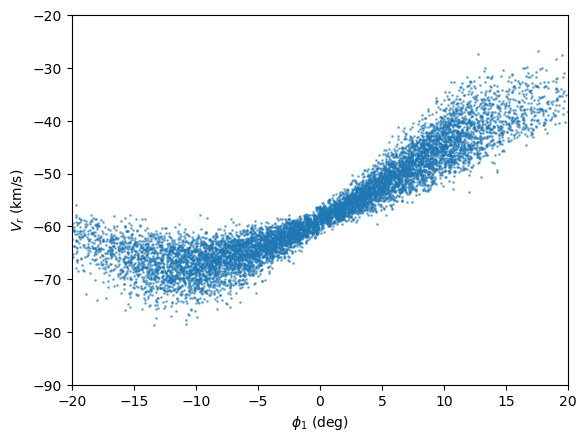

In [243]:
stream_pal5 = stream_c.transform_to(Pal5())

plt.scatter(stream_pal5.phi1.wrap_at(180*u.deg), stream_pal5.radial_velocity, s=1, alpha=0.5)

plt.xlabel(r'$\phi_1$ (deg)')
plt.ylabel(r'$V_r$ (km/s)')
plt.xlim(-20,20)
plt.ylim(-90,-20)
plt.show()

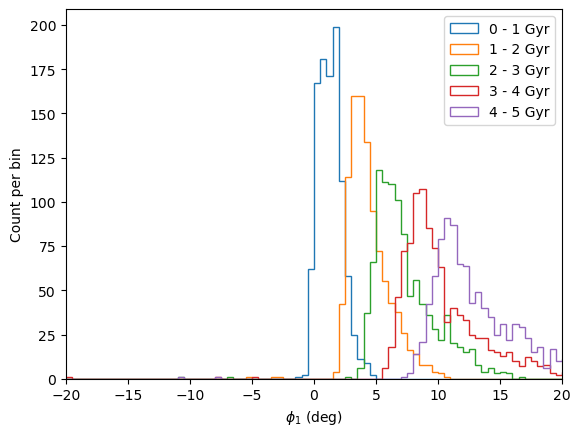

In [276]:
bins = np.arange(0,5001,1000)
digitized = np.digitize(stream.release_time, -bins*u.Myr)

for i in range(1, len(bins)):
    plt.hist(stream_pal5.phi1.wrap_at(180*u.deg)[(digitized==i)&(stream.lead_trail=='t')], bins=np.arange(-20,21,0.5)*u.deg, histtype='step', 
        label=r'%g - %g Gyr'%(bins[i-1]/1000, bins[i]/1000))

plt.xlabel(r'$\phi_1$ (deg)')
plt.ylabel(r'Count per bin')
plt.xlim(-20,20)
plt.legend()
plt.show()

In [415]:
from scipy.signal import find_peaks

def get_peri_apo(x,y,z):
    r2 = x**2 + y**2 + z**2
    median = np.median(r2)
    peaks_apo, _ = find_peaks(r2, height=median)
    peaks_peri, _ = find_peaks(-r2, height=-median)

    return peaks_apo, peaks_peri

df = ms.ChenStreamDF()
gen_pal5 = ms.MockStreamGenerator(df, pot, progenitor_potential=pal5_pot)
t_tot = 1000 * u.Myr
dt = 1 * u.Myr
n_steps = int(t_tot/dt)

orbit = pot.integrate_orbit(pal5_w0, dt=-dt, n_steps=n_steps)

pos = orbit.pos.xyz.value.T
vel = orbit.vel.d_xyz.to('km/s').value.T

apos, peris = get_peri_apo(pos[:,0], pos[:,1], pos[:,2])
T = np.mean(peris[1:] - peris[:-1])
Tfrac = 0.1
Tsig = Tfrac * T
N = 1000
rate = np.zeros(n_steps+1)
for peri in [peris[0]]:
    t_to_peri2 = (np.arange(n_steps+1) - peri)**2
    rate += N*0.398942/Tsig*np.exp(-0.5*t_to_peri2/Tsig**2)/len(peris)

rate = np.round(rate).astype(int)

%time stream, _ = gen_pal5.run(pal5_w0, pal5_mass, dt=-dt, n_steps=n_steps, n_particles=rate[::-1])

CPU times: user 267 ms, sys: 3.24 ms, total: 271 ms
Wall time: 275 ms


In [410]:
peris

array([178, 485, 787])

In [406]:
orbit.t

<Quantity [    0.,    -5.,   -10., ..., -4990., -4995., -5000.] Myr>

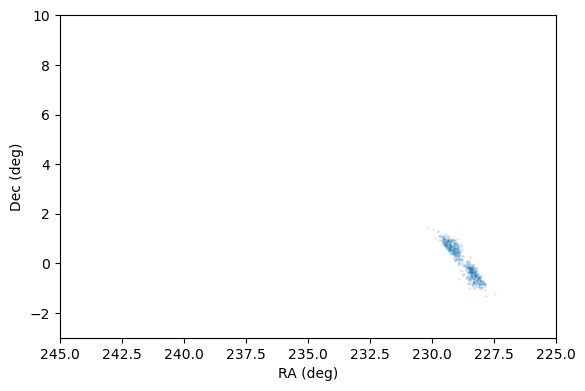

In [416]:
stream_c = stream.to_coord_frame(coord.ICRS())
# stream_c_f15 = stream_f15.to_coord_frame(coord.ICRS())

plt.scatter(stream_c.ra, stream_c.dec, s=1, alpha=0.1)
# plt.scatter(stream_c_f15.ra, stream_c_f15.dec, s=1, alpha=0.1)

plt.xlabel(r'RA (deg)')
plt.ylabel(r'Dec (deg)')
plt.xlim(245,225)
plt.ylim(-3,10)
plt.gca().set_aspect(1)
plt.show()

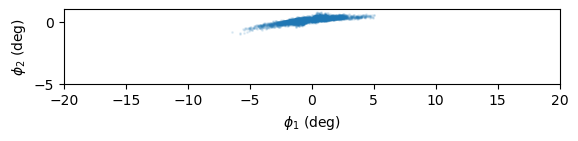

In [385]:
stream_pal5 = stream_c.transform_to(Pal5())
# stream_pal5_f15 = stream_c_f15.transform_to(Pal5())

plt.scatter(stream_pal5.phi1.wrap_at(180*u.deg), stream_pal5.phi2, s=1, alpha=0.1)
# plt.scatter(stream_pal5_f15.phi1.wrap_at(180*u.deg), stream_pal5_f15.phi2, s=1, alpha=0.1)

plt.xlabel(r'$\phi_1$ (deg)')
plt.ylabel(r'$\phi_2$ (deg)')
plt.xlim(-20,20)
plt.ylim(-5,1)
plt.gca().set_aspect(1)
plt.show()

In [318]:
orbit.vel

<CartesianDifferential (d_x, d_y, d_z) in kpc / Myr
    [(-0.04266034, -0.10937797, -0.01679116),
     (-0.04181111, -0.1093476 , -0.01494435),
     (-0.04096062, -0.10930604, -0.01310268), ...,
     (-0.07672021,  0.16700998, -0.11154873),
     (-0.07892554,  0.16900368, -0.11012955),
     (-0.08114909,  0.17098966, -0.10865831)]>

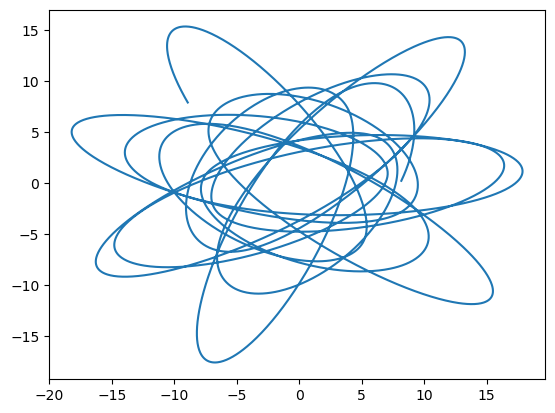

In [321]:
plt.plot(orbit.pos.x, orbit.pos.y)

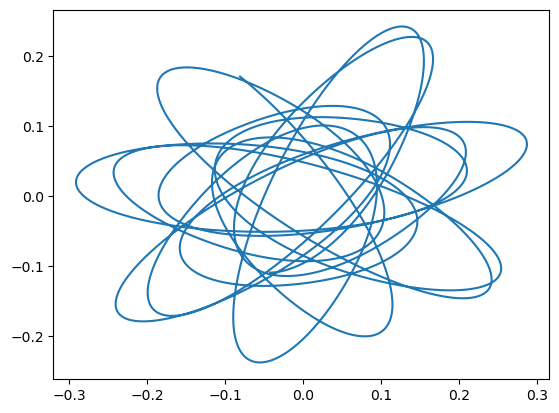

In [320]:
plt.plot(orbit.vel.d_x, orbit.vel.d_y)